# Human Evaluation of CFE: Springer Publication Deep Dive
This notebook analyzes the results of a survey focused on the human-centric evaluation of Counterfactual Explanations (CFEs). Participants evaluated 4 selection algorithms: **TOPSIS (k=1)**, **Balanced Point (BP)**, **Ideal Point (IP)**, and **Random Point (RP)** across 5 different CelebA instances (`q1`, `q5`, `q7`, `q13`, `q15`).

We leverage the existing `survey_parser.py` module to load and parse the data cleanly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import custom parser
from survey_parser import load_config, parse_results

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [2]:
# --- 1. Load and Parse Data ---
survey_config = load_config('config.json')
parsed_results = parse_results(survey_config, 'results.csv')
df = pd.read_csv('results.csv')

print(f"Loaded {len(df)} survey responses.")

Loaded 152 survey responses.


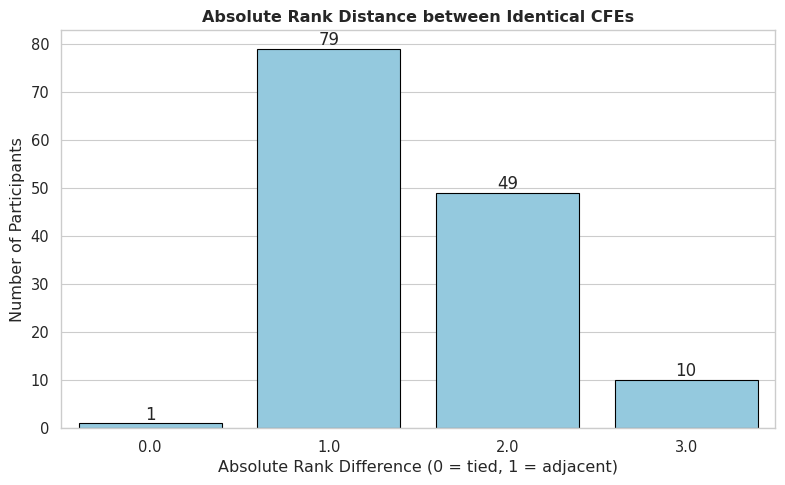

In [3]:
# Extract rankings for the duplicated CFEs in q1
topsis_col = 'q1_topsis_pos'
ip_col = 'q1_IP_pos'

if topsis_col in df.columns and ip_col in df.columns:
    # Calculate absolute difference in rank positions
    df['q1_dupe_dist'] = (df[topsis_col] - df[ip_col]).abs()
    
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='q1_dupe_dist', data=df, color='skyblue', edgecolor='black')
    plt.title('Absolute Rank Distance between Identical CFEs', fontweight='bold')
    plt.xlabel('Absolute Rank Difference (0 = tied, 1 = adjacent)')
    plt.ylabel('Number of Participants')
    
    # Add value annotations on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    plt.savefig("dist_absolute_rank_dist.png")
    plt.show()
else:
    print("Ranking columns for q1 TOPSIS and IP were not found in the DataFrame.")

In [4]:
# Identify how many participants used the tie mechanic across ranking questions
ranking_qs = [q.id for q in survey_config.ranking_questions if q.images]
tie_users_per_q = {}
any_tie_users = pd.Series(False, index=df.index)

for q_id in ranking_qs:
    # Find columns belonging to this question (e.g. q1_topsis_pos, q1_BP_pos)
    cols = [c for c in df.columns if c.startswith(f"{q_id}_") and c.endswith("_pos")]
    if cols:
        # A tie exists if there are duplicate valid ranks for this user in this question
        has_tie = df[cols].apply(lambda row: row.dropna().duplicated().any(), axis=1)
        tie_users_per_q[q_id] = has_tie.sum()
        any_tie_users = any_tie_users | has_tie

total_tie_users = any_tie_users.sum()
total_participants = len(df)

print(f"Total participants who used a tie at least once: {total_tie_users} out of {total_participants} ({(total_tie_users/total_participants)*100:.1f}%)")
print("\nTie usage per question:")
for q_id, count in tie_users_per_q.items():
    print(f"{q_id}: {count} participants")

Total participants who used a tie at least once: 93 out of 152 (61.2%)

Tie usage per question:
q1: 51 participants
q5: 22 participants
q7: 27 participants
q13: 46 participants
q15: 71 participants


In [5]:
survey_config = load_config('config.json')

# Load and filter the dataframe
df = pd.read_csv('results.csv')

topsis_col = 'q1_topsis_pos'
ip_col = 'q1_IP_pos'
df['q1_dupe_dist'] = (df[topsis_col] - df[ip_col]).abs()

# Overwrite df with the filtered version
df = df[df['q1_dupe_dist'].le(1) | df['q1_dupe_dist'].isna()].copy()

# Save the filtered data to a temporary CSV
temp_csv_path = 'results_filtered.csv'
df.to_csv(temp_csv_path, index=False)

# Feed the filtered CSV to the original parser
parsed_results = parse_results(survey_config, temp_csv_path)

print(f"Loaded {len(df)} survey responses.")

Loaded 93 survey responses.


## 2. Global Performance & Statistical Significance
To determine if the observed differences in rankings are statistically significant, we will employ a Kruskal-Wallis H-test

In [6]:
# Extract all rankings globally across all 5 CelebA questions
selectors = ['IP', 'BP', 'RP', 'topsis']
ranking_qs = [q.id for q in survey_config.ranking_questions if q.images]

ranks_per_selector = {s: [] for s in selectors}
for s in selectors:
    for q in ranking_qs:
        col = f"{q}_{s}_pos"
        if col in df.columns:
            ranks_per_selector[s].extend(df[col].dropna().tolist())

# Print Mean Ranks
print("Global Mean Ranks (Lower is Better):")
for s in selectors:
    mean_rank = np.mean(ranks_per_selector[s])
    print(f"{s:8}: {mean_rank:.3f}")

# Run Kruskal-Wallis H-test
print("\n--- Kruskal-Wallis H-Test ---")
h_stat, p_val = stats.kruskal(*[ranks_per_selector[s] for s in selectors])
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: We REJECT the null hypothesis. The differences in rankings between the CFE selectors are statistically significant.")
else:
    print("\nConclusion: We FAIL TO REJECT the null hypothesis. There is no statistically significant difference in rankings.")

Global Mean Ranks (Lower is Better):
IP      : 1.790
BP      : 2.629
RP      : 3.042
topsis  : 2.012

--- Kruskal-Wallis H-Test ---
H-statistic: 332.0119
p-value:     1.1704e-71

Conclusion: We REJECT the null hypothesis. The differences in rankings between the CFE selectors are statistically significant.


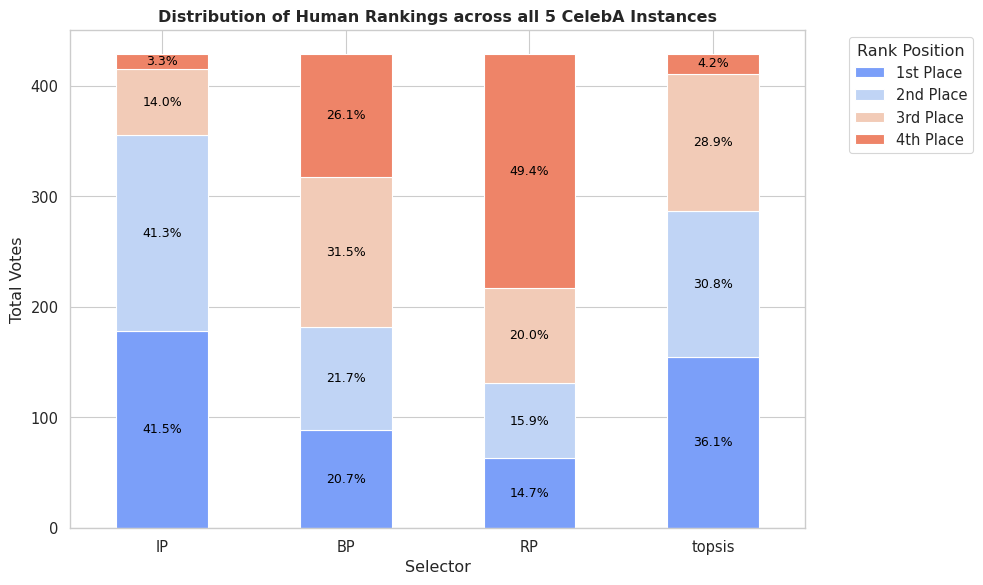

In [7]:
# Visualize the distribution of ranks per selector
agg_counts = {s: {1: 0, 2: 0, 3: 0, 4: 0} for s in selectors}

for q_id in ranking_qs:
    for s in selectors:
        for rank, count in parsed_results[q_id].ranking_counts.get(s, {}).items():
            agg_counts[s][rank] += count
            
total_ranks = next(map(lambda ds: sum(ds.values()), agg_counts.values()))

agg_df = pd.DataFrame(agg_counts).T
agg_df.columns = ['1st Place', '2nd Place', '3rd Place', '4th Place']

colors = sns.color_palette("coolwarm", 4)
ax = agg_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)


# Add percentage labels on the bars for extra clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only show label if the segment is large enough
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height / total_ranks * 100:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=9,
                color='black')

plt.title('Distribution of Human Rankings across all 5 CelebA Instances', fontweight='bold')
plt.xlabel('Selector')
plt.ylabel('Total Votes')
plt.xticks(rotation=0)
plt.legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('human_rankings_selector.png')
plt.show()

In [8]:
import pickle

import os
import sys
sys.path.append(os.path.abspath('../../src'))
from explainers_lib.ensemble import cfs_group_by_original_data

PICKLE_FILE_PATH = "../results/evaluate_selectors_celeba_20260313_071238.pkl"
EXTRA_CFS = "../results/evaluate_selectors_celeba_20260421_123022_dice_face_after_fix.pkl"

with open(PICKLE_FILE_PATH, "rb") as f:
    all_generated_cfes = pickle.load(f)

with open(EXTRA_CFS, "rb") as f:
    extra_cfs = pickle.load(f)

extra_cfs = filter(lambda cfe: cfe.original_class == 1, extra_cfs)
all_generated_cfes.extend(extra_cfs)

print(f"Successfully loaded {len(all_generated_cfes)} counterfactuals.")

# Group them by original instance
grouped_cfs = cfs_group_by_original_data(all_generated_cfes)

Successfully loaded 440 counterfactuals.


In [9]:
import re
regex = re.compile(r"(_explainer)?\(.*\)")

qid_to_cfe_id = { q: int(q[1:]) for q in ranking_qs } # TODO: do i need to -1?
cfs = list(grouped_cfs.values())
cfs = [cfs[idx] for idx in qid_to_cfe_id.values()]
cfs_methods = list(map(lambda cfe_i: list(map(lambda cf: regex.sub("", cf.explainer), cfe_i)), cfs))

all_methods = list({item for sublist in cfs_methods for item in sublist})
all_methods

['wachter', 'dice', 'cfproto', 'face', 'growing_spheres']

In [10]:
with open("../results/evaluate_selectors_celeba_20260423_172842_scores.pkl", "rb") as f:
    scores = pickle.load(f)
    scores_map = scores["scores_map"]
    results_by_selector = scores["results_by_selector"]

sel_to_s = { sel: s for sel, s in zip(sorted(results_by_selector.keys() - ["ParetoMeanPoint"], key = lambda k: k[0]), sorted(selectors, key = lambda k: k[0]))}
sel_to_s

{'BalancedPoint': 'BP',
 'IdealPoint': 'IP',
 'RandomPoint': 'RP',
 'TOPSIS': 'topsis'}

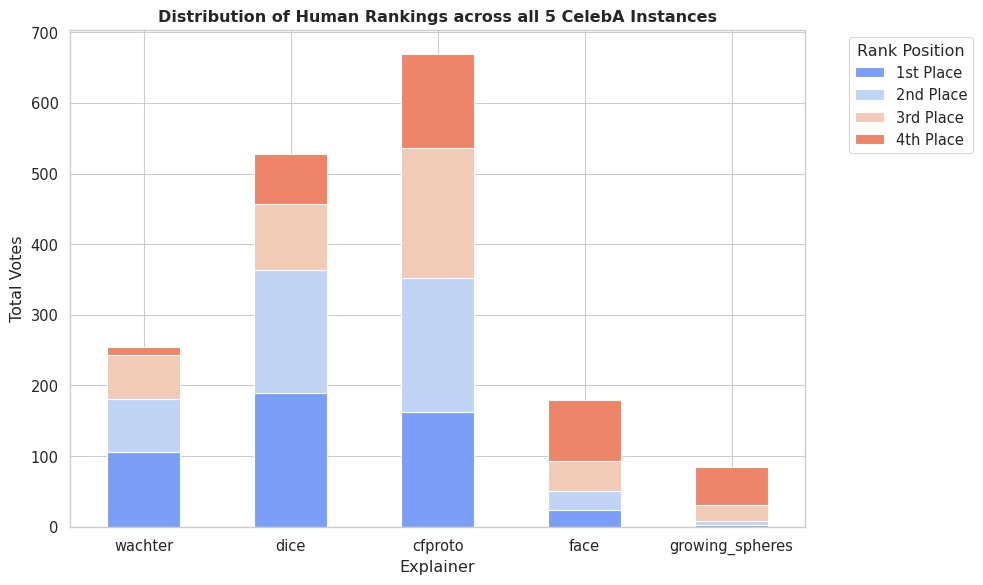

In [11]:
# Visualize the distribution of ranks per explainer
agg_counts = {s: {1: 0, 2: 0, 3: 0, 4: 0} for s in all_methods}

for i, q_id in enumerate(ranking_qs):
    seen_sel = {"ParetoMeanPoint"}
    for cf in cfs[i]:
        for sel in results_by_selector:
            if sel in seen_sel:
                continue
            if cf.data.tobytes() in results_by_selector[sel]:
                seen_sel.add(sel)
                for rank, count in parsed_results[q_id].ranking_counts.get(sel_to_s[sel], {}).items():
                    agg_counts[regex.sub("", cf.explainer)][rank] += count

agg_df = pd.DataFrame(agg_counts).T
agg_df.columns = ['1st Place', '2nd Place', '3rd Place', '4th Place']

colors = sns.color_palette("coolwarm", 4)
ax = agg_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title('Distribution of Human Rankings across all 5 CelebA Instances', fontweight='bold')
plt.xlabel('Explainer')
plt.ylabel('Total Votes')
plt.xticks(rotation=0)
plt.legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

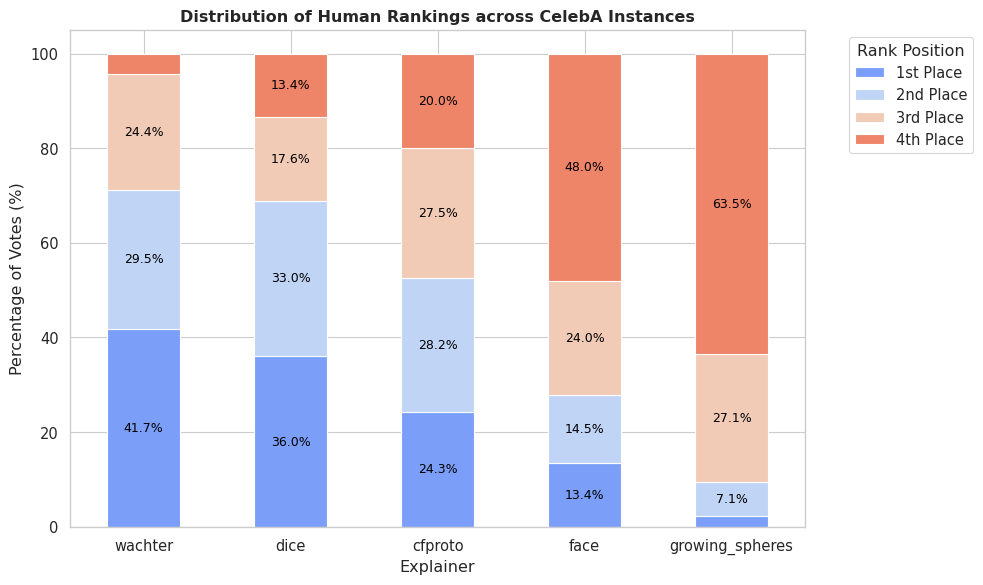

In [12]:
agg_pct = agg_df.div(agg_df.sum(axis=1), axis=0) * 100

# Visualize
colors = sns.color_palette("coolwarm", 4)
# Use agg_pct instead of agg_df
ax = agg_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title('Distribution of Human Rankings across CelebA Instances', fontweight='bold')
plt.xlabel('Explainer')
plt.ylabel('Percentage of Votes (%)')
plt.xticks(rotation=0)

# Add percentage labels on the bars for extra clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only show label if the segment is large enough
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                fontsize=9,
                color='black')

plt.legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('human_rankings_explainer.png')
plt.show()

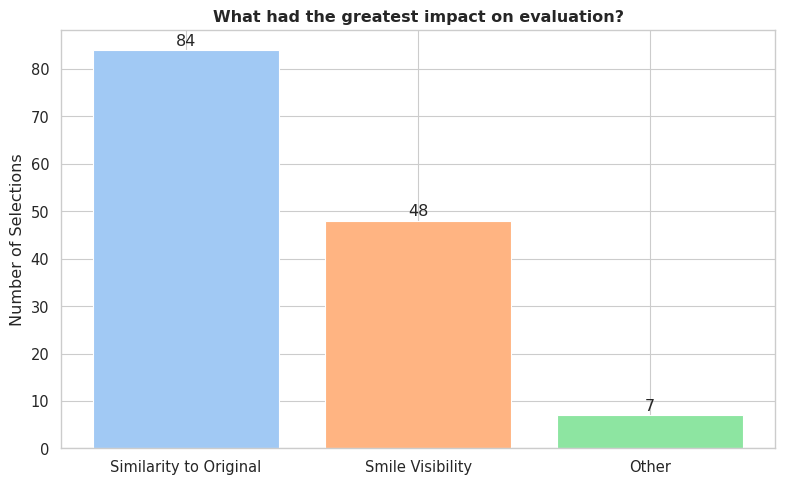

In [13]:
criteria_counts = parsed_results['q_most_important_criterion'].counts
labels = {'similarity': 'Similarity to Original', 'smile': 'Smile Visibility', 'other': 'Other'}

# Map to english labels
mapped_counts = {labels.get(k, k): v for k, v in criteria_counts.items() if v > 0}

plt.figure(figsize=(8, 5))
plt.bar(mapped_counts.keys(), mapped_counts.values(), color=sns.color_palette("pastel"))
plt.title('What had the greatest impact on evaluation?', fontweight='bold')
plt.ylabel('Number of Selections')
for i, v in enumerate(mapped_counts.values()):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig("primary_criterion.png")
plt.show()

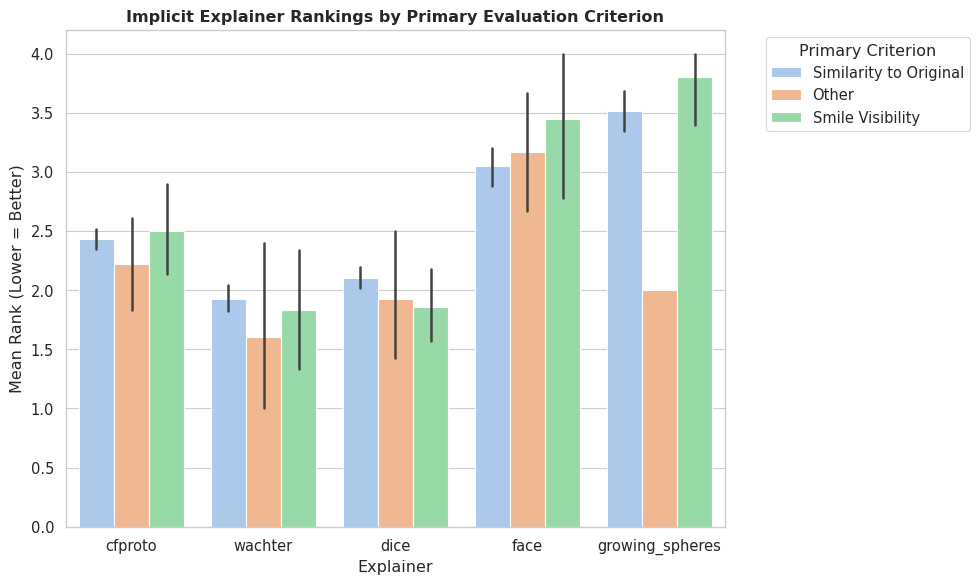

In [14]:
# 1. Build a mapping from (Question, Selector) -> Explainer
q_sel_to_explainer = {q: {} for q in ranking_qs}
for i, q_id in enumerate(ranking_qs):
    seen_sel = {"ParetoMeanPoint"}
    for cf in cfs[i]:
        for sel in results_by_selector:
            if sel in seen_sel:
                continue
            if cf.data.tobytes() in results_by_selector[sel]:
                seen_sel.add(sel)
                # sel_to_s maps 'IdealPoint' to 'IP', regex cleans the explainer name
                q_sel_to_explainer[q_id][sel_to_s[sel]] = regex.sub("", cf.explainer)

# 2. Extract and format row-level explainer rankings correlated to user criteria
explainer_rows = []
labels_map = {'similarity': 'Similarity to Original', 'smile': 'Smile Visibility', 'other': 'Other'}

for idx, row in df.iterrows():
    # Parse the user's primary evaluation criterion
    crit = row.get('q_most_important_criterion')
    if pd.isna(crit) or crit == 'Not Specified':
        continue
        
    primary_crit = str(crit).split(';')[0]
    crit_label = labels_map.get(primary_crit, 'Other')

    # Convert their selector ranks to the respective explainer ranks
    for q in ranking_qs:
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and pd.notna(row[col]):
                explainer_name = q_sel_to_explainer[q].get(s, "Unknown")
                explainer_rows.append({
                    'Subject_ID': idx,
                    'Explainer': explainer_name,
                    'Rank': row[col],
                    'Primary_Criterion': crit_label
                })

df_explainer_ranks = pd.DataFrame(explainer_rows)
df_explainer_ranks = df_explainer_ranks[df_explainer_ranks['Explainer'] != 'Unknown']

# 3. Visualize the relationship
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_explainer_ranks,
    x='Explainer',
    y='Rank',
    hue='Primary_Criterion',
    errorbar=('ci', 95),
    palette='pastel'
)
plt.title('Implicit Explainer Rankings by Primary Evaluation Criterion', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('Explainer')
plt.legend(title='Primary Criterion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Demographic Alignment (Global Trends vs. Subgroup Preferences)
Are the results universal, or do individuals familiar with Machine Learning / Explainability rank the criteria differently? We melt the dataframe to analyze the interaction between demographics and ranks.

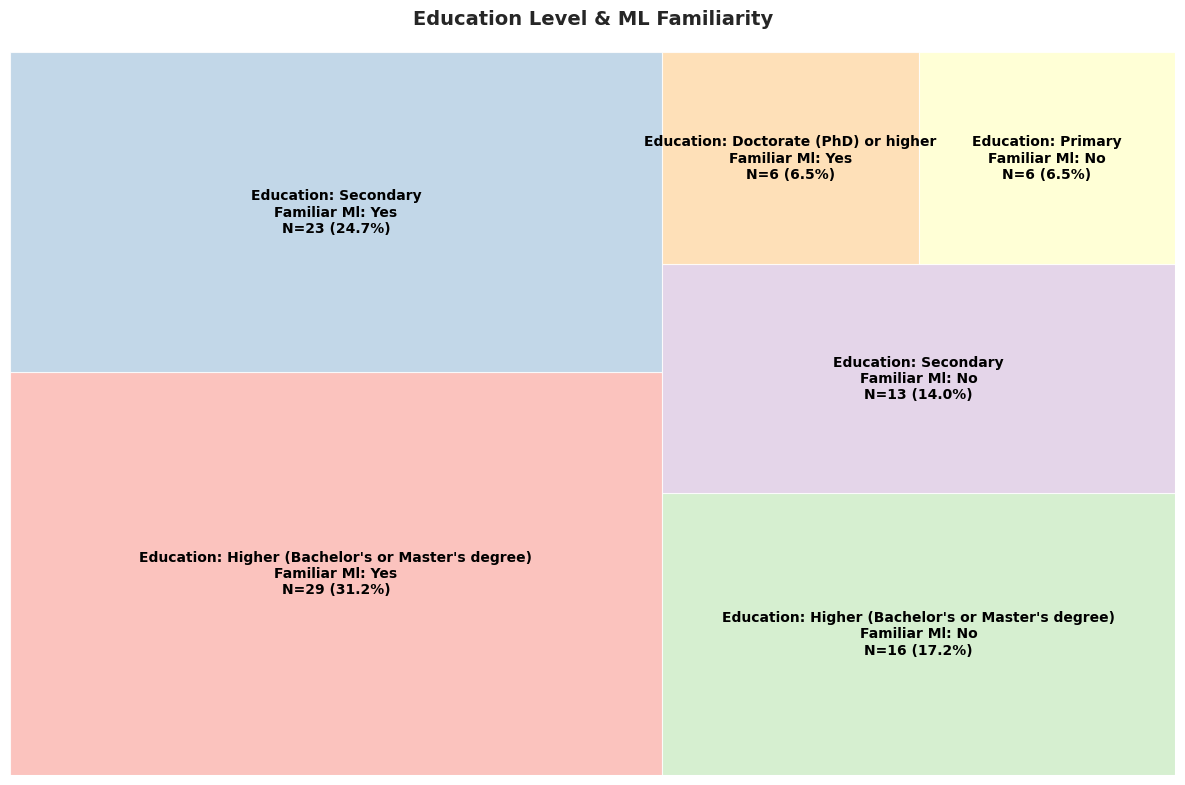

In [15]:
import squarify

def plot_treemap(df_subset, hierarchy_cols, title, color_palette='Pastel1'):
    # Group data by the hierarchy and count occurrences
    grouped = df_subset.groupby(hierarchy_cols).size().reset_index(name='count')
    grouped = grouped[grouped['count'] > 0]
    grouped = grouped.sort_values(by='count', ascending=False)
    
    total = grouped['count'].sum()
    
    # Create rich labels: e.g. "Higher Ed\nML: Yes\nN=45 (42%)"
    labels = []
    for _, row in grouped.iterrows():
        label_parts = [f"{col.replace('_', ' ').title()}: {row[col]}" for col in hierarchy_cols]
        pct = (row['count'] / total) * 100
        label = "\n".join(label_parts) + f"\nN={row['count']} ({pct:.1f}%)"
        labels.append(label)
        
    plt.figure(figsize=(12, 8))
    colors = sns.color_palette(color_palette, len(grouped))
    
    squarify.plot(
        sizes=grouped['count'], 
        label=labels, 
        color=colors, 
        alpha=0.8, 
        text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'black'}
    )
    
    plt.title(title, fontweight='bold', pad=20, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Treemap 1: Education Level ➔ ML Familiarity ---
# We keep 'Not Specified' here if it exists, or fill it.
df_p1 = df.copy()
df_p1['education'] = df_p1['education'].fillna('Not Specified')
df_p1['familiar_ml'] = df_p1['familiar_ml'].fillna('Not Specified')
plot_treemap(
    df_p1, 
    ['education', 'familiar_ml'], 
    'Education Level & ML Familiarity',
    color_palette='Pastel1'
)

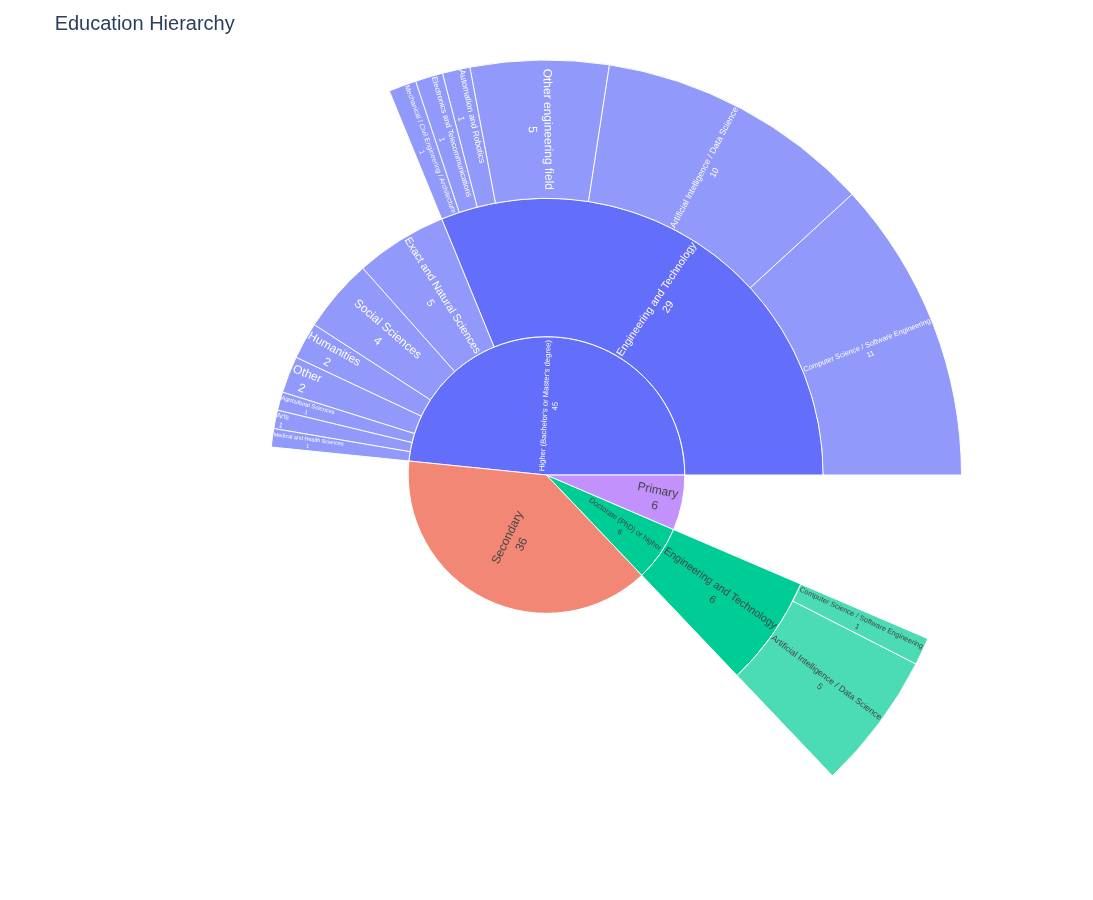

In [16]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

df_p2 = df.copy()
pipeline_cols = ['education', 'education_field', 'engineering_specialization']

# 1. Standardize missing values
cleanup_values = ['N/A', '', ' ', 'nan', 'NaN', 'None', '<NA>']
df_p2[pipeline_cols] = df_p2[pipeline_cols].replace(cleanup_values, np.nan)

# 2. Build the exact tree structure manually
ids = []
labels = []
parents = []
values = []

for ed, df_ed in df_p2.groupby('education', dropna=False):
    if pd.isna(ed): continue # Drop missing roots
    
    ed_id = str(ed)
    ids.append(ed_id)
    labels.append(str(ed))
    parents.append("")
    values.append(len(df_ed))
    
    for field, df_field in df_ed.groupby('education_field', dropna=False):
        if pd.isna(field): continue # Drop missing fields!
        
        field_id = f"{ed_id}|{field}"
        ids.append(field_id)
        labels.append(str(field))
        parents.append(ed_id)
        values.append(len(df_field))
        
        for spec, df_spec in df_field.groupby('engineering_specialization', dropna=False):
            if pd.isna(spec): continue # Drop missing specializations!
            
            spec_id = f"{field_id}|{spec}"
            ids.append(spec_id)
            labels.append(str(spec))
            parents.append(field_id)
            values.append(len(df_spec))

# 3. Plot using the lower-level Graph Objects
fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total", # THE MAGIC: Tells Plotly to leave unmatched parent space blank!
    textinfo="label+value", # Shows the category and the count cleanly
    insidetextorientation='radial' # Makes the text rotate with the slices for better reading
))

fig.update_layout(
    title="Education Hierarchy",
    title_font=dict(size=20, family="Arial"),
    width=900,
    height=900,
    margin=dict(t=60, l=10, r=10, b=10)
)

# 4. Force a static image render to bypass Jupyter's JS blocking
fig.show()

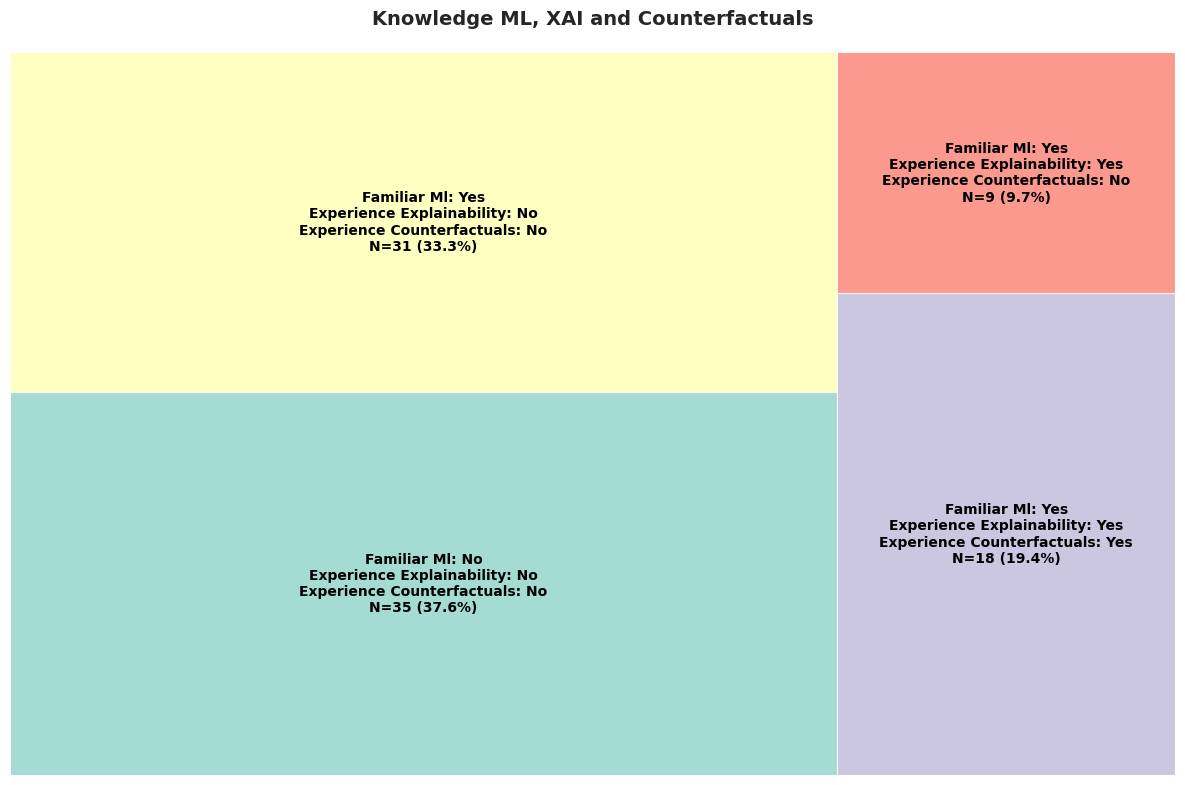

In [17]:
# --- Treemap 2: ML Familiarity ➔ Experience with Explainability ➔ Experience with CFEs ---
df_p2 = df.copy()
pipeline_cols = ['familiar_ml', 'experience_explainability', 'experience_counterfactuals']

# Replace any missing values with 'No'
df_p2[pipeline_cols] = df_p2[pipeline_cols].fillna('No')

plot_treemap(
    df_p2, 
    pipeline_cols, 
    'Knowledge ML, XAI and Counterfactuals',
    color_palette='Set3'
)

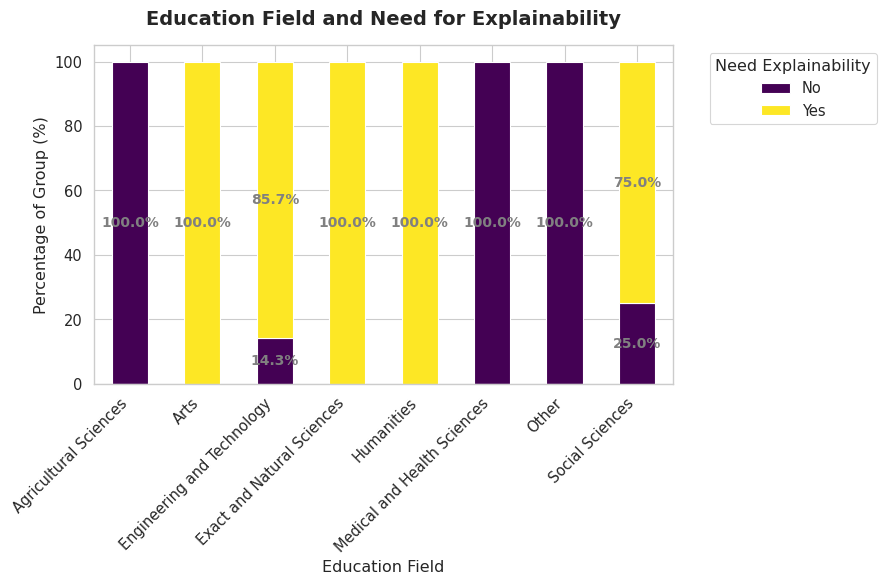

In [18]:
def plot_100_percent_stacked(df_source, col_x, col_hue, title):
    # Remove NaNs for cleaner visual comparison
    temp_df = df_source.dropna(subset=[col_x, col_hue]).copy()
    
    # Calculate cross-tabulation percentages (rows sum to 100%)
    crosstab = pd.crosstab(temp_df[col_x], temp_df[col_hue], normalize='index') * 100
    
    # Plot
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='viridis', edgecolor='white')
    plt.title(title, fontweight='bold', pad=15, fontsize=14)
    plt.ylabel('Percentage of Group (%)')
    plt.xlabel(col_x.replace('_', ' ').title())
    
    # Move Legend outside
    plt.legend(title=col_hue.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    
    # Annotate percentages inside the bars
    for c in ax.containers:
        labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='gray', weight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()

# 3. Education Field ➔ Need for Explainability
plot_100_percent_stacked(
    df, 
    'education_field', 
    'need_explainability', 
    'Education Field and Need for Explainability'
)

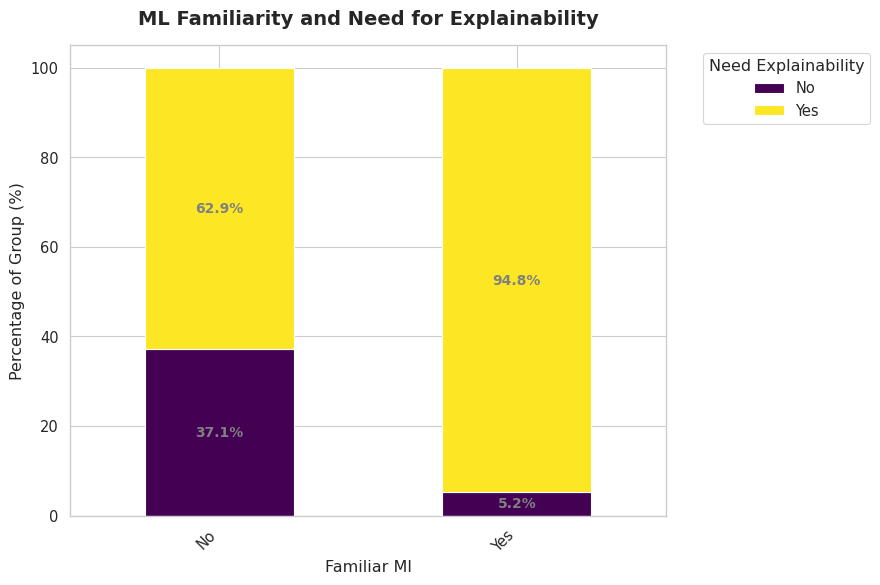

In [19]:
# 4. ML Familiarity ➔ Need for Explainability
plot_100_percent_stacked(
    df, 
    'familiar_ml', 
    'need_explainability', 
    'ML Familiarity and Need for Explainability'
)

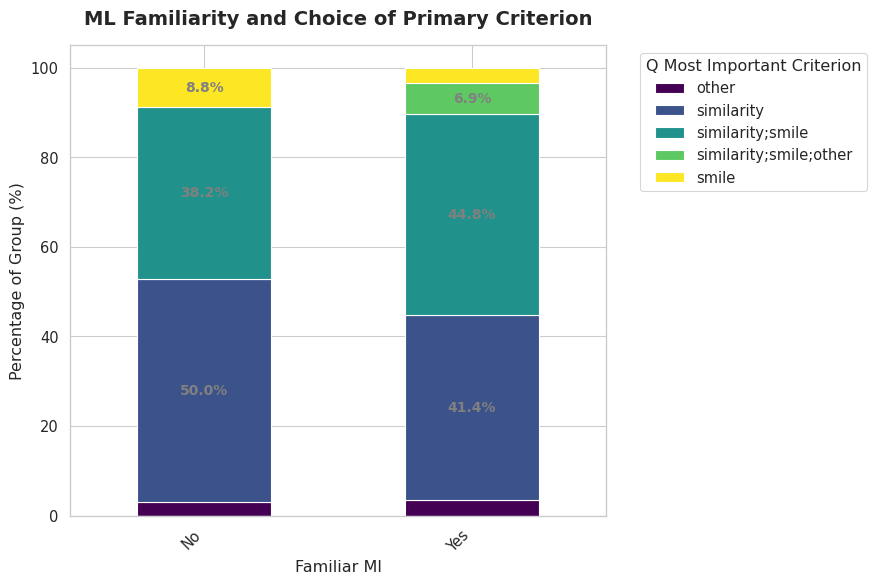

In [20]:
# 5. ML Familiarity ➔ Primary Criterion Choice (Similarity vs Smile)
temp_df = df[df['q_most_important_criterion'] != 'Not Specified'].copy()
plot_100_percent_stacked(
    temp_df, 
    'familiar_ml', 
    'q_most_important_criterion', 
    'ML Familiarity and Choice of Primary Criterion'
)

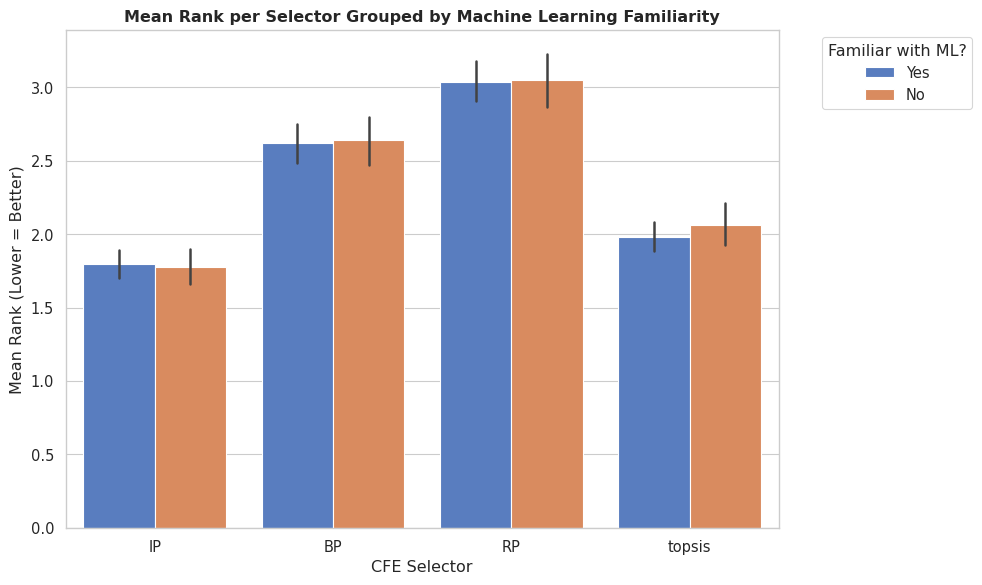

In [21]:
# Restructure data for Seaborn Factor plots
melted_rows = []
for idx, row in df.iterrows():
    for q in ranking_qs:
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and pd.notna(row[col]):
                melted_rows.append({
                    'Subject_ID': idx,
                    'Selector': s,
                    'Rank': row[col],
                    'ML_Familiarity': row.get('familiar_ml', 'Unknown'),
                    'Education': row.get('education', 'Unknown'),
                    'Need_Explainability': row.get('need_explainability', 'Unknown')
                })

df_ranks = pd.DataFrame(melted_rows)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='ML_Familiarity', 
    errorbar=('ci', 95),
    palette='muted'
)
plt.title('Mean Rank per Selector Grouped by Machine Learning Familiarity', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Familiar with ML?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

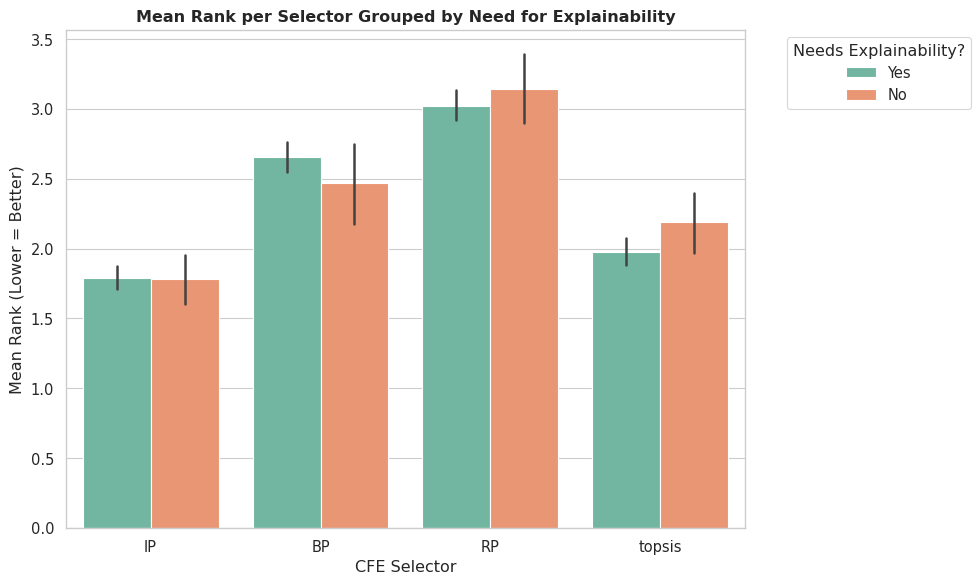

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='Need_Explainability', 
    errorbar=('ci', 95),
    palette='Set2'
)
plt.title('Mean Rank per Selector Grouped by Need for Explainability', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Needs Explainability?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

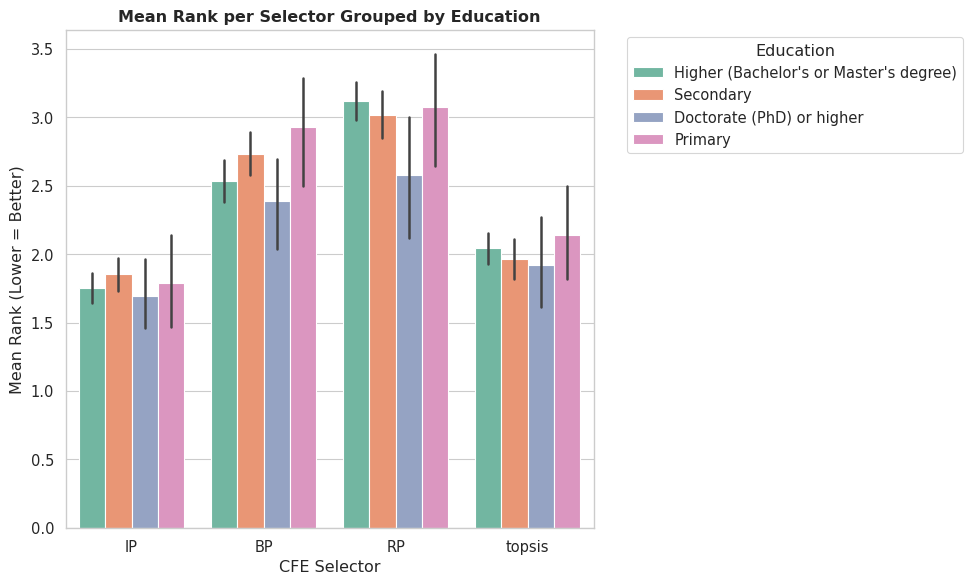

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_ranks, 
    x='Selector', 
    y='Rank', 
    hue='Education', 
    errorbar=('ci', 95),
    palette='Set2'
)
plt.title('Mean Rank per Selector Grouped by Education', fontweight='bold')
plt.ylabel('Mean Rank (Lower = Better)')
plt.xlabel('CFE Selector')
plt.legend(title='Education', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Data Mining

In [24]:
# --- 1. User-Level Aggregation (Fractional Weighting for Ties) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import re

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Load data
df = pd.read_csv('results_filtered.csv')

q_ids = ['q1', 'q5', 'q7', 'q13', 'q15']
selectors = ['IP', 'BP', 'RP', 'topsis']
demographics = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 
                'experience_counterfactuals', 'need_explainability', 
                'education', 'education_field', 'q_most_important_criterion']

df[demographics] = df[demographics].fillna('Missing')

user_data = []

for idx, row in df.iterrows():
    top_choices = []
    for q in q_ids:
        for s in selectors:
            col = f"{q}_{s}_pos"
            if col in df.columns and row[col] == 1.0:
                top_choices.append(s)
    
    if top_choices:
        # Find all tied winners (if there's a clear winner, len(modes) == 1)
        modes = pd.Series(top_choices).mode().tolist()
        
        # Split the user's 1.0 vote equally among the ties
        weight = 1.0 / len(modes)
        
        for m in modes:
            entry = {d: row[d] for d in demographics}
            entry['Subject_ID'] = idx
            entry['overall_top_selector'] = m
            entry['sample_weight'] = weight
            user_data.append(entry)

df_user = pd.DataFrame(user_data)
print(f"Processed {len(df)} users into {len(df_user)} weighted preference rows.")
print(f"Total voting weight preserved: {df_user['sample_weight'].sum():.1f} (i.i.d. satisfied)")

Processed 93 users into 135 weighted preference rows.
Total voting weight preserved: 93.0 (i.i.d. satisfied)


In [25]:
# --- 2. Feature Engineering (Corrected for Multi-Select) ---

# 1. XAI Expertise Score (0 to 4)
knowledge_cols = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 'experience_counterfactuals']
df_user['xai_expertise'] = df_user[knowledge_cols].apply(lambda x: sum(x == 'Yes'), axis=1)

# 2. STEM vs Non-STEM
stem_fields = ['Engineering and Technology', 'Exact and Natural Sciences', 'Medical and Health Sciences', 'Agricultural Sciences']
df_user['is_stem'] = df_user['education_field'].apply(lambda x: 'Yes' if x in stem_fields else 'No')

# 3. Handle Multi-Select Evaluation Criteria (Multi-Hot Encoding)
# We check if the specific string exists anywhere in the user's combined answer
df_user['crit_similarity'] = df_user['q_most_important_criterion'].apply(
    lambda x: 1 if pd.notna(x) and 'similarity' in str(x) else 0
)
df_user['crit_smile'] = df_user['q_most_important_criterion'].apply(
    lambda x: 1 if pd.notna(x) and 'smile' in str(x) else 0
)
df_user['crit_other'] = df_user['q_most_important_criterion'].apply(
    lambda x: 1 if pd.notna(x) and 'other' in str(x) else 0
)

# Prepare final modeling dataframe
modeling_features = ['xai_expertise', 'is_stem', 'need_explainability', 
                     'crit_similarity', 'crit_smile', 'crit_other']

X_raw = df_user[modeling_features]
y = df_user['overall_top_selector']

# Encode ONLY the remaining categorical features (is_stem, need_explainability)
# xai_expertise, crit_similarity, crit_smile, crit_other are already numeric
X = X_raw.copy()
mapping_dict = {}

cats_to_encode = ['is_stem', 'need_explainability']
for col in cats_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    mapping_dict[col] = {i: name for i, name in enumerate(le.classes_)}

print("Features engineered and encoded. Multi-select criteria properly preserved as boolean columns.")

Features engineered and encoded. Multi-select criteria properly preserved as boolean columns.


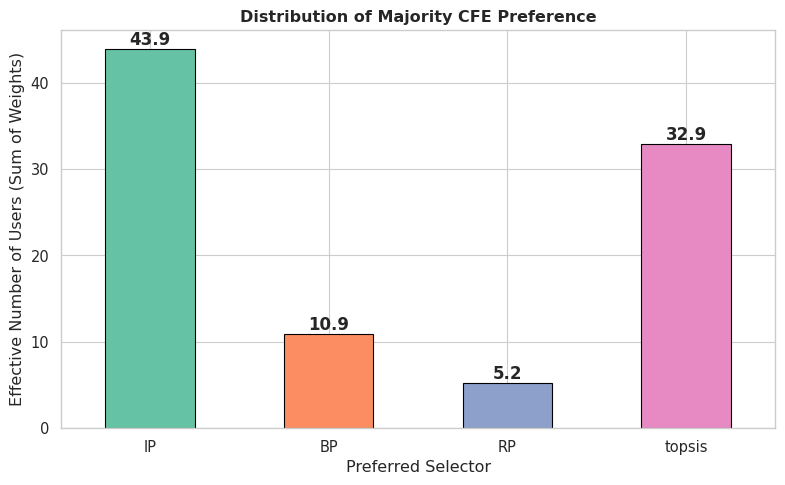

In [26]:
# --- Visualizing the Target Class Balance (Weighted) ---
plt.figure(figsize=(8, 5))

# Group by selector and sum the fractional weights
weighted_counts = df_user.groupby('overall_top_selector')['sample_weight'].sum().reindex(['IP', 'BP', 'RP', 'topsis'])

ax = weighted_counts.plot(kind='bar', color=sns.color_palette('Set2', 4), edgecolor='black')

plt.title('Distribution of Majority CFE Preference', fontweight='bold')
plt.xlabel('Preferred Selector')
plt.ylabel('Effective Number of Users (Sum of Weights)')
plt.xticks(rotation=0)

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_98082/2439117959.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_98082/2439117959.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_98082/2439117959.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_98082/2439117959.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




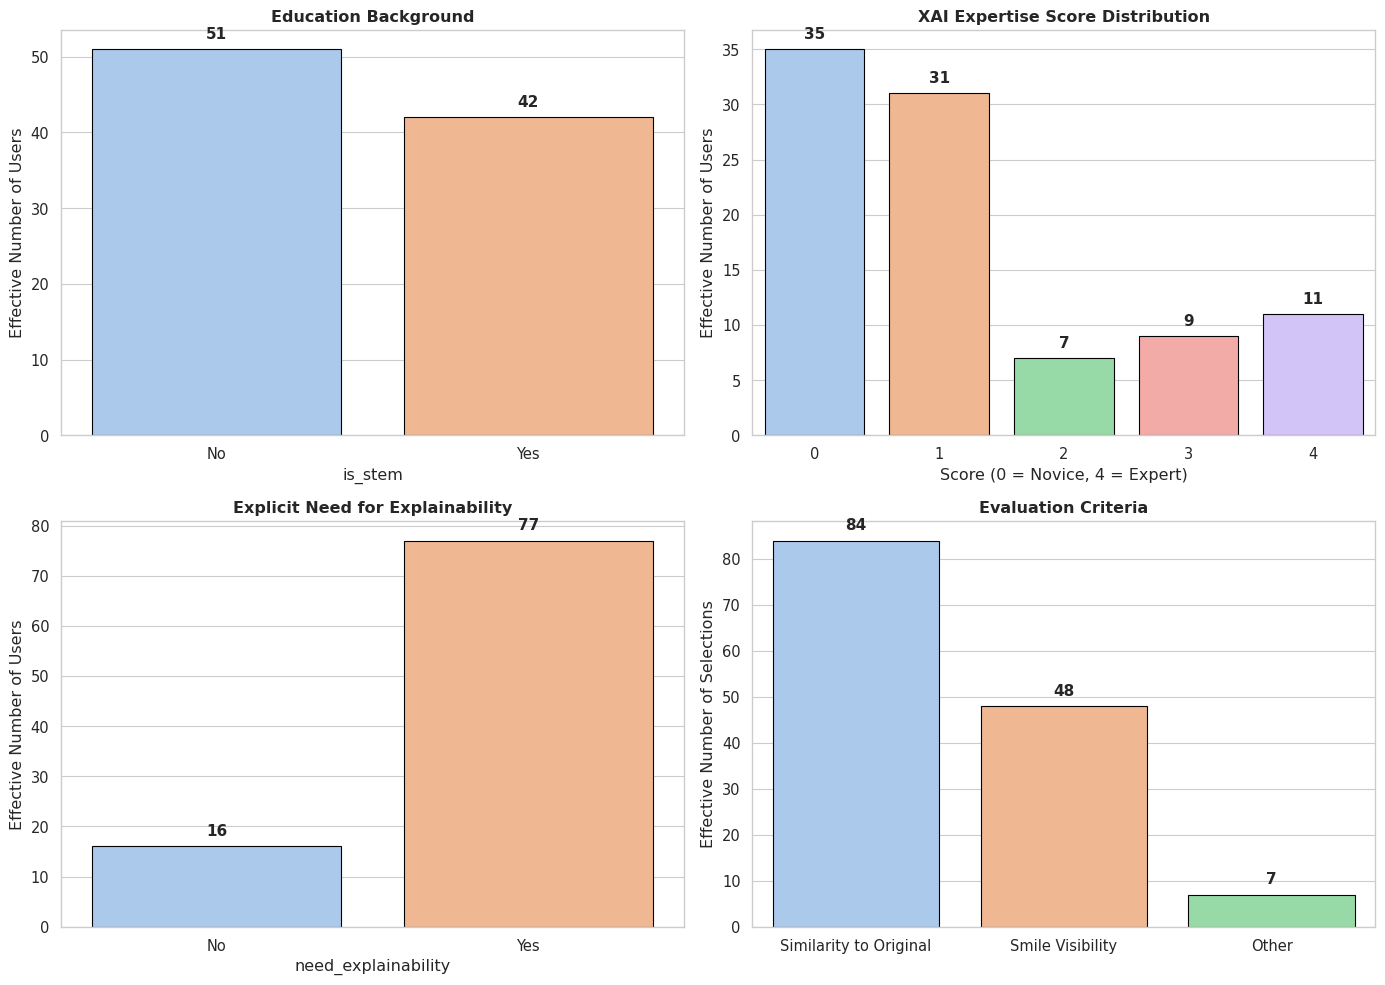

In [27]:
# --- Visualizing Demographic Distributions (Corrected for Fractional Weights) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper function to plot weighted counts
def plot_weighted_bar(ax, group_col, title, xlabel=None):
    # Sum the sample weights instead of counting rows!
    counts = df_user.groupby(group_col)['sample_weight'].sum()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='pastel', edgecolor='black')
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Effective Number of Users')
    if xlabel:
        ax.set_xlabel(xlabel)
        
    # Add values on top of bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.02, int(v), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 1: STEM vs Non-STEM
plot_weighted_bar(axes[0,0], 'is_stem', 'Education Background')

# Plot 2: XAI Expertise
plot_weighted_bar(axes[0,1], 'xai_expertise', 'XAI Expertise Score Distribution', 'Score (0 = Novice, 4 = Expert)')

# Plot 3: Need Explainability
plot_weighted_bar(axes[1,0], 'need_explainability', 'Explicit Need for Explainability')

# Plot 4: Stated Criterion (Multi-Select + Fractional Weights Fix)
# Multiply the binary column (1 or 0) by the sample_weight, then sum it up
crit_similarity_weighted = (df_user['crit_similarity'] * df_user['sample_weight']).sum()
crit_smile_weighted = (df_user['crit_smile'] * df_user['sample_weight']).sum()
crit_other_weighted = (df_user['crit_other'] * df_user['sample_weight']).sum()

crit_sums = [crit_similarity_weighted, crit_smile_weighted, crit_other_weighted]
crit_labels = ['Similarity to Original', 'Smile Visibility', 'Other']

sns.barplot(x=crit_labels, y=crit_sums, ax=axes[1,1], palette='pastel', edgecolor='black')
axes[1,1].set_title('Evaluation Criteria', fontweight='bold')
axes[1,1].set_ylabel('Effective Number of Selections')

# Add exact counts on top of bars
for i, v in enumerate(crit_sums):
    axes[1,1].text(i, v + max(crit_sums)*0.02, int(v), 
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("demographics.png")
plt.show()

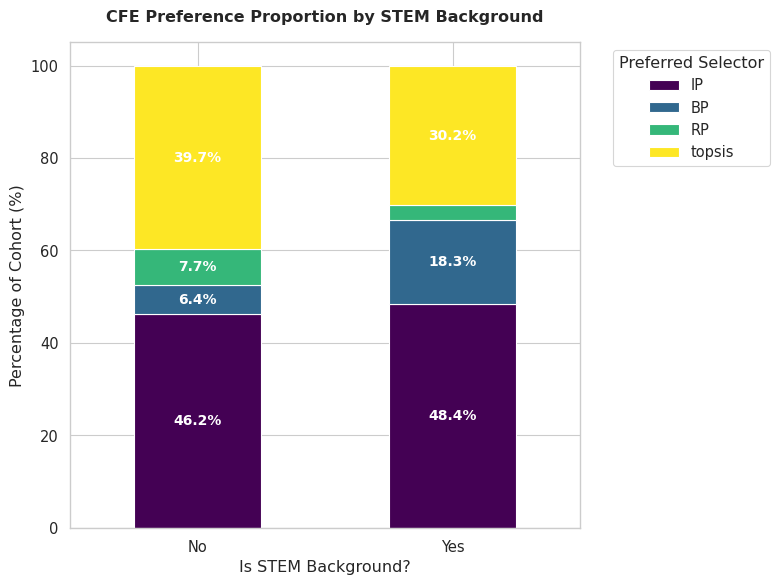

In [28]:
# --- Visualizing the Significant Interaction (is_stem vs Preference) ---

# Corrected crosstab: Use sample_weights to handle fractional ties accurately
crosstab = pd.crosstab(
    index=df_user['is_stem'], 
    columns=df_user['overall_top_selector'], 
    values=df_user['sample_weight'],      # Use the fractional weights!
    aggfunc='sum',                        # Sum the weights instead of counting rows
    normalize='index'
) * 100

# Enforce consistent column ordering to match your other plots
crosstab = crosstab[['IP', 'BP', 'RP', 'topsis']]

# Plot 100% stacked bar chart
ax = crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis', edgecolor='white')

plt.title('CFE Preference Proportion by STEM Background', fontweight='bold', pad=15)
plt.ylabel('Percentage of Cohort (%)')
plt.xlabel('Is STEM Background?')
plt.xticks(rotation=0)

# Move Legend outside
plt.legend(title='Preferred Selector', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate percentages inside the bars for absolute clarity
for c in ax.containers:
    # Only show label if the bar section is large enough (>5%)
    labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', weight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("preference_by_stem.png")
plt.show()

/tmp/ipykernel_98082/896864621.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




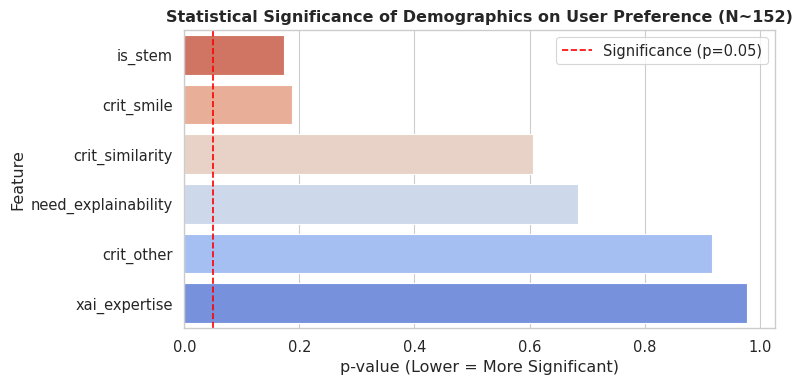

In [29]:
# --- 3. Re-run Chi-Square Tests at User Level ---
chi_results = []
for d in modeling_features:
    contingency = pd.crosstab(df_user[d], df_user['overall_top_selector'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({'Feature': d, 'p_value': p})

df_chi = pd.DataFrame(chi_results).sort_values('p_value')

plt.figure(figsize=(8, 4))
sns.barplot(data=df_chi, x='p_value', y='Feature', palette='coolwarm_r')
plt.axvline(0.05, color='red', linestyle='--', label='Significance (p=0.05)')
plt.title('Statistical Significance of Demographics on User Preference (N~152)', fontweight='bold')
plt.xlabel('p-value (Lower = More Significant)')
plt.legend()
plt.tight_layout()
plt.savefig("significance.png")
plt.show()

/tmp/ipykernel_98082/4259973785.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




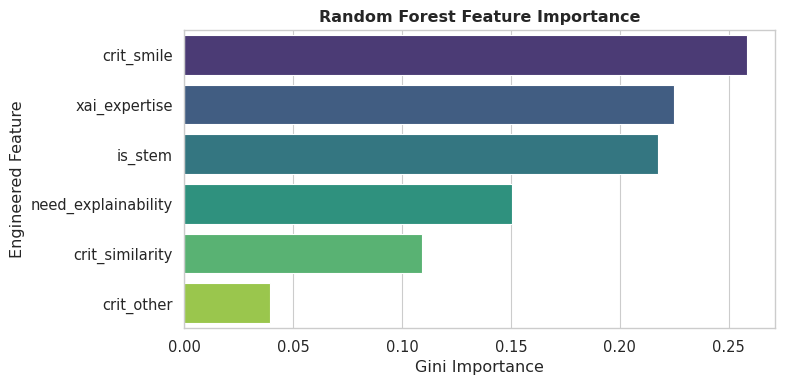

In [30]:
# --- 4. Random Forest Feature Importance ---
# Extract the weights
weights = df_user['sample_weight'].values

# With N~150, we must constrain the forest to prevent overfitting
rf = RandomForestClassifier(
    n_estimators=500, 
    random_state=42, 
    class_weight='balanced',
    max_depth=3,          # Prevent deep, complex rules
    min_samples_leaf=5    # Prevent leaves that isolate single users
)

# Pass the weights into the fit function!
rf.fit(X, y, sample_weight=weights)

importances = pd.Series(rf.feature_importances_, index=modeling_features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest Feature Importance', fontweight='bold')
plt.xlabel('Gini Importance')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.savefig("gini_importance.png")
plt.show()

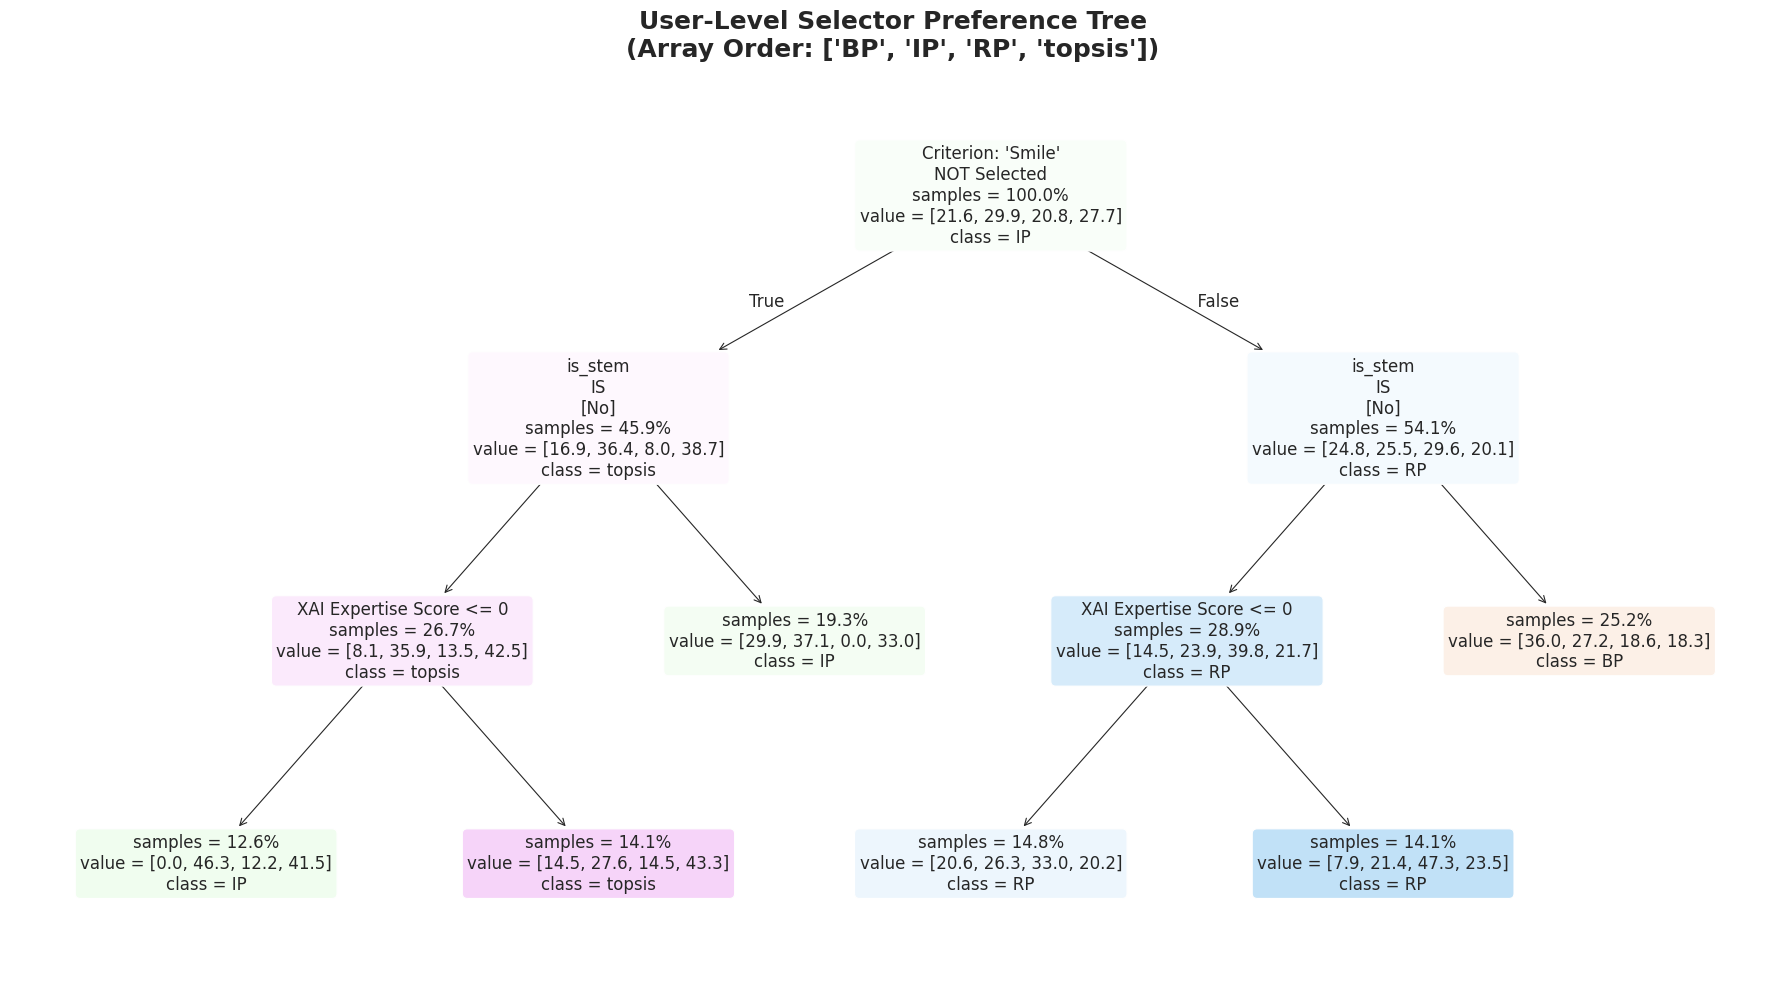

In [31]:
# --- 5. Interpretable Decision Tree (Strictly Regularized) ---
dt_final = DecisionTreeClassifier(
    random_state=42, 
    class_weight='balanced', 
    # max_depth=3,           
    min_samples_leaf=17
)
dt_final.fit(X, y, sample_weight=weights)

plt.figure(figsize=(18, 10))
annotations = plot_tree(
    dt_final, 
    feature_names=modeling_features, 
    class_names=dt_final.classes_, 
    filled=True, 
    rounded=True, 
    impurity=False, 
    fontsize=12,
    proportion=True
)

# Clean up tree text (Translate Categorical and Boolean Inequalities)
for text_obj in annotations:
    text = text_obj.get_text()
    lines = text.split('\n')
    
    if '<=' in lines[0]:
        match = re.match(r"(.+) <= ([\d\.]+)", lines[0])
        if match:
            feature = match.group(1)
            threshold = float(match.group(2))
            
            # 1. Handle Expertise Score
            if feature == 'xai_expertise':
                lines[0] = f"XAI Expertise Score <= {int(threshold)}"
            
            # 2. Handle Multi-Hot Boolean Criteria
            elif feature.startswith('crit_'):
                clean_name = feature.replace('crit_', '').title()
                # If threshold is 0.5 and we go left (True), it means the value was 0 (Not Selected)
                lines[0] = f"Criterion: '{clean_name}'\nNOT Selected"
                
            # 3. Handle Label Encoded Categories
            elif feature in mapping_dict:
                left_classes = [name for i, name in mapping_dict[feature].items() if i <= threshold]
                if len(left_classes) == 1:
                    lines[0] = f"{feature}\nIS\n[{left_classes[0]}]"
                elif len(left_classes) > 2:
                    right_classes = [name for i, name in mapping_dict[feature].items() if i > threshold]
                    lines[0] = f"{feature}\nNOT IN\n[{', '.join(right_classes)}]"
                else:
                    lines[0] = f"{feature}\nIN\n[{', '.join(left_classes)}]"
                    
    # Reformat value arrays to clean integers
    for i, line in enumerate(lines):
        if line.startswith('value'):
            match = re.search(r'\[(.*?)\]', line)
            if match:
                vals = [round(float(x.strip()) * 100, 2 ) for x in match.group(1).split(',')]
                lines[i] = f"value = {vals}"
                
    text_obj.set_text('\n'.join(lines))

plt.title(f"User-Level Selector Preference Tree\n(Array Order: {list(dt_final.classes_)})", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("decision_tree.png")
plt.show()

In [32]:
# Calculate the exact weighted percentages for the whole cohort
weighted_sums = df_user.groupby('overall_top_selector')['sample_weight'].sum()
true_percentages = (weighted_sums / weighted_sums.sum()) * 100

print("True Weighted Percentages (Matches the Root Node):")
print(true_percentages.round(1))


True Weighted Percentages (Matches the Root Node):
overall_top_selector
BP        11.7
IP        47.2
RP         5.6
topsis    35.4
Name: sample_weight, dtype: float64
